In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller

In [3]:
all_prices_file = "all_prices.csv"


temp_df = pd.read_csv(all_prices_file)
print(temp_df.head())
print(temp_df.columns.tolist())

         Date   ALI_F     XLB       PICK        DBB         AA       CENX  \
0  2018-01-02  2244.5  30.695  35.680000  19.459999  55.169998  21.379999   
1  2018-01-03  2244.5  30.910  36.119999  19.260000  54.500000  20.480000   
2  2018-01-04  2244.5  31.180  36.009998  19.370001  54.700001  20.540001   
3  2018-01-05  2244.5  31.430  35.939999  19.170000  54.090000  19.940001   
4  2018-01-08  2244.5  31.475  36.590000  19.139999  55.000000  19.709999   

         KALU        RIO  NHYDY        ACH   CSTM  S32.AX  HINDALCO.NS  \
0  109.419998  54.750000   7.72  19.370001  11.45    3.51   271.899994   
1  109.349998  54.950001   7.56  19.150000  11.65    3.58   276.500000   
2  110.900002  54.700001   7.57  19.219999  11.95    3.56   279.799988   
3  110.339996  54.540001   7.54  19.870001  11.80    3.65   276.399994   
4  111.190002  55.650002   7.44  19.820000  11.85    3.65   276.149994   

     1211.HK  
0  23.216665  
1  23.733334  
2  23.533333  
3  23.299999  
4  23.366667  
['

In [4]:
tickers = [
    "ALI_F", "AA", "ACH", "CENX", "CSTM", "DBB",
    "HINDALCO.NS", "KALU", "NHYDY", "PICK",
    "RIO", "S32.AX", "XLB", "1211.HK"
]

df = pd.read_csv(all_prices_file)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

needed_cols = ["Date"] + tickers
df = df[needed_cols].copy()

for col in tickers:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)

df.head()

,Date,ALI_F,AA,ACH,CENX,CSTM,DBB,HINDALCO.NS,KALU,NHYDY,PICK,RIO,S32.AX,XLB,1211.HK
0,2018-01-02,2244.5,55.169998,19.370001,21.379999,11.45,19.459999,271.899994,109.419998,7.72,35.680000,54.750000,3.51,30.695,23.216665
1,2018-01-03,2244.5,54.500000,19.150000,20.480000,11.65,19.260000,276.500000,109.349998,7.56,36.119999,54.950001,3.58,30.910,23.733334
2,2018-01-04,2244.5,54.700001,19.219999,20.540001,11.95,19.370001,279.799988,110.900002,7.57,36.009998,54.700001,3.56,31.180,23.533333
3,2018-01-05,2244.5,54.090000,19.870001,19.940001,11.80,19.170000,276.399994,110.339996,7.54,35.939999,54.540001,3.65,31.430,23.299999
4,2018-01-08,2244.5,55.000000,19.820000,19.709999,11.85,19.139999,276.149994,111.190002,7.44,36.590000,55.650002,3.65,31.475,23.366667


In [5]:
df.columns

Index(['Date', 'ALI_F', 'AA', 'ACH', 'CENX', 'CSTM', 'DBB', 'HINDALCO.NS',
       'KALU', 'NHYDY', 'PICK', 'RIO', 'S32.AX', 'XLB', '1211.HK'],
      dtype='object')

In [6]:
print(df.shape)
df.tail()

(1579, 15)


,Date,ALI_F,AA,ACH,CENX,CSTM,DBB,HINDALCO.NS,KALU,NHYDY,PICK,RIO,S32.AX,XLB,1211.HK
1574,2024-12-20,2481.00,37.840000,12.52,18.330000,10.31,19.740000,622.650024,69.779999,5.49,35.290001,58.639999,3.34,42.790001,89.000000
1575,2024-12-23,2477.25,38.580002,12.56,18.870001,10.33,18.910000,634.150024,70.089996,5.51,35.369999,59.230000,3.41,42.535000,89.866669
1576,2024-12-24,2532.00,38.610001,12.72,19.010000,10.33,19.070000,627.450012,70.389999,5.51,35.430000,59.200001,3.41,42.764999,91.466667
1577,2024-12-27,2530.00,37.680000,12.95,18.410000,10.19,19.040001,617.400024,69.320000,5.48,35.259998,59.009998,3.40,42.470001,91.199997
1578,2024-12-30,2545.25,37.150002,12.66,18.230000,9.97,18.959999,601.099976,70.000000,5.50,34.860001,58.590000,3.40,41.900002,89.400002


In [7]:
anchor = "ALI_F"
equities = ["AA", "ACH", "CENX", "CSTM", "HINDALCO.NS", "KALU", "NHYDY", "RIO", "S32.AX", "1211.HK"]

In [8]:
for col in [anchor] + equities:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)
print(df.shape)

(1579, 15)


In [9]:
def test_pair_cointegration(data, anchor_col, equity_col, train_ratio=0.75):
    pair_df = data[["Date", anchor_col, equity_col]].dropna().copy()
    
    split = int(len(pair_df) * train_ratio)
    train = pair_df.iloc[:split].copy()
    
    x = np.log(train[anchor_col])
    y = np.log(train[equity_col])
    
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    
    alpha = model.params["const"]
    beta = model.params[anchor_col]
    
    spread = y - (alpha + beta * x)
    
    adf_result = adfuller(spread.dropna(), regression="c", autolag="AIC")
    p_value = adf_result[1]
    
    return {
        "equity": equity_col,
        "p_value": p_value,
        "beta": beta,
        "alpha": alpha
    }

In [10]:
results = []

for eq in equities:
    try:
        res = test_pair_cointegration(df, anchor, eq)
        results.append(res)
    except Exception as e:
        print(f"Problem with {eq}: {e}")

screening = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
screening

,equity,p_value,beta,alpha
0,NHYDY,0.011629,1.871660,-12.789467
1,AA,0.012126,2.788058,-18.039309
2,CENX,0.029653,1.645287,-10.350616
3,CSTM,0.053747,1.052427,-5.601254
4,KALU,0.093326,0.426285,1.255401
5,S32.AX,0.128652,1.105960,-7.354578
6,RIO,0.183266,0.491141,0.337294
7,HINDALCO.NS,0.263079,1.945496,-9.381950
8,ACH,0.391914,2.703427,-18.066747
9,1211.HK,0.655991,2.513313,-15.816645


In [11]:
best_equity = screening.loc[0, "equity"]
best_beta = screening.loc[0, "beta"]
best_alpha = screening.loc[0, "alpha"]

print("Best equity:", best_equity)
print("Best beta:", best_beta)
print("Best alpha:", best_alpha)

Best equity: NHYDY
Best beta: 1.8716603485480592
Best alpha: -12.789467080563838


In [12]:
pair_df = df[["Date", anchor, best_equity]].dropna().copy()

pair_df["log_anchor"] = np.log(pair_df[anchor])
pair_df["log_equity"] = np.log(pair_df[best_equity])

pair_df["spread"] = pair_df["log_equity"] - (best_alpha + best_beta * pair_df["log_anchor"])

pair_df.head()

,Date,ALI_F,NHYDY,log_anchor,log_equity,spread
0,2018-01-02,2244.5,7.72,7.716238,2.043814,0.391105
1,2018-01-03,2244.5,7.56,7.716238,2.022871,0.370161
2,2018-01-04,2244.5,7.57,7.716238,2.024193,0.371483
3,2018-01-05,2244.5,7.54,7.716238,2.020222,0.367512
4,2018-01-08,2244.5,7.44,7.716238,2.006871,0.354161


In [13]:
split = int(len(pair_df) * 0.75)

train_df = pair_df.iloc[:split].copy()
test_df = pair_df.iloc[split:].copy()

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 1184
Test size: 395


In [14]:
def compute_zscore(series, lookback):
    rolling_mean = series.rolling(lookback).mean()
    rolling_std = series.rolling(lookback).std()
    zscore = (series - rolling_mean) / rolling_std
    return zscore

In [15]:
def backtest_strategy(data, lookback, entry_z=1.5, exit_z=0.5, vol_lookback=30, vol_threshold=1.5, trailing_stop=0.025):
    df_bt = data.copy()
    
    df_bt["zscore"] = compute_zscore(df_bt["spread"], lookback)
    df_bt["spread_ret"] = df_bt["spread"].diff()
    df_bt["vol"] = df_bt["spread_ret"].rolling(vol_lookback).std()
    
    median_vol = df_bt["vol"].median()
    df_bt["vol_ok"] = df_bt["vol"] < vol_threshold * median_vol
    
    df_bt["asset_ret"] = df_bt[best_equity].pct_change()
    df_bt["anchor_ret"] = df_bt[anchor].pct_change()
    df_bt["pair_ret"] = df_bt["asset_ret"] - best_beta * df_bt["anchor_ret"]
    
    position = 0
    positions = []
    strategy_returns = []
    
    trade_pnl = 0
    best_trade_pnl = 0
    
    for i in range(len(df_bt)):
        if i == 0:
            positions.append(0)
            strategy_returns.append(0)
            continue
        
        z = df_bt["zscore"].iloc[i-1]
        vol_ok = df_bt["vol_ok"].iloc[i-1]
        pair_ret = df_bt["pair_ret"].iloc[i]
        
        daily_ret = position * pair_ret
        
        if position != 0:
            trade_pnl += daily_ret
            if trade_pnl > best_trade_pnl:
                best_trade_pnl = trade_pnl
        
        if position != 0 and (best_trade_pnl - trade_pnl > trailing_stop):
            position = 0
            trade_pnl = 0
            best_trade_pnl = 0
        
        elif position != 0 and abs(z) < exit_z:
            position = 0
            trade_pnl = 0
            best_trade_pnl = 0
        
        elif position == 0 and vol_ok:
            if z < -entry_z:
                position = 1
                trade_pnl = 0
                best_trade_pnl = 0
            elif z > entry_z:
                position = -1
                trade_pnl = 0
                best_trade_pnl = 0
        
        strategy_returns.append(daily_ret)
        positions.append(position)
    
    df_bt["position"] = positions
    df_bt["strategy_ret"] = strategy_returns
    
    return df_bt

In [16]:
lookbacks = [20, 30, 40, 60, 90, 120]
grid_results = []

for lb in lookbacks:
    bt_train = backtest_strategy(train_df, lookback=lb)
    
    ret = bt_train["strategy_ret"].fillna(0)
    mean_ret = ret.mean()
    vol_ret = ret.std()
    
    if vol_ret != 0:
        sharpe = (mean_ret / vol_ret) * np.sqrt(252)
    else:
        sharpe = np.nan
    
    total_return = (1 + ret).cumprod().iloc[-1] - 1
    
    grid_results.append({
        "lookback": lb,
        "train_sharpe": sharpe,
        "train_total_return": total_return
    })

grid_df = pd.DataFrame(grid_results).sort_values("train_sharpe", ascending=False).reset_index(drop=True)
grid_df

,lookback,train_sharpe,train_total_return
0,40,0.524887,0.637633
1,20,0.473968,0.558097
2,60,0.443379,0.541311
3,90,0.289346,0.231439
4,120,0.226539,0.129478
5,30,0.206116,0.092940


In [17]:
best_lookback = int(grid_df.loc[0, "lookback"])
print("Best lookback =", best_lookback)

Best lookback = 40


In [18]:
bt_test = backtest_strategy(test_df, lookback=best_lookback)
bt_test.head()

,Date,ALI_F,NHYDY,log_anchor,log_equity,spread,zscore,spread_ret,vol,vol_ok,asset_ret,anchor_ret,pair_ret,position,strategy_ret
1184,2023-03-27,2341.75,7.09,7.758654,1.958685,0.226588,NaN,NaN,NaN,False,NaN,NaN,NaN,0,0.0
1185,2023-03-28,2370.25,7.29,7.770751,1.986504,0.231765,NaN,0.005177,NaN,False,0.028209,0.012170,0.005430,0,0.0
1186,2023-03-29,2360.00,7.29,7.766417,1.986504,0.239876,NaN,0.008111,NaN,False,0.000000,-0.004324,0.008094,0,0.0
1187,2023-03-31,2383.75,7.48,7.776430,2.012233,0.246864,NaN,0.006988,NaN,False,0.026063,0.010064,0.007228,0,0.0
1188,2023-04-03,2378.75,7.68,7.774330,2.038620,0.277181,NaN,0.030317,NaN,False,0.026738,-0.002098,0.030664,0,0.0


In [19]:
def performance_metrics(returns):
    returns = returns.fillna(0)
    
    equity_curve = (1 + returns).cumprod()
    total_return = equity_curve.iloc[-1] - 1
    
    annual_return = (1 + total_return) ** (252 / len(returns)) - 1
    annual_vol = returns.std() * np.sqrt(252)
    
    if annual_vol != 0:
        sharpe = annual_return / annual_vol
    else:
        sharpe = np.nan
    
    rolling_max = equity_curve.cummax()
    drawdown = equity_curve / rolling_max - 1
    max_drawdown = drawdown.min()
    
    if max_drawdown != 0:
        calmar = annual_return / abs(max_drawdown)
    else:
        calmar = np.nan
    
    return {
        "Total Return": total_return,
        "Annual Return": annual_return,
        "Annual Volatility": annual_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "Calmar": calmar
    }

In [20]:
strategy_metrics = performance_metrics(bt_test["strategy_ret"])
strategy_metrics

{'Total Return': -0.11929206326618969,
 'Annual Return': -0.07784451175939333,
 'Annual Volatility': 0.23388480582196333,
 'Sharpe': -0.33283270149087735,
 'Max Drawdown': -0.1993430987798367,
 'Calmar': -0.39050517542806057}

In [21]:
bh_returns = test_df[best_equity].pct_change().fillna(0)
bh_metrics = performance_metrics(bh_returns)

print("Strategy metrics:")
print(strategy_metrics)

print("\nBuy and Hold metrics:")
print(bh_metrics)

Strategy metrics:
{'Total Return': -0.11929206326618969, 'Annual Return': -0.07784451175939333, 'Annual Volatility': 0.23388480582196333, 'Sharpe': -0.33283270149087735, 'Max Drawdown': -0.1993430987798367, 'Calmar': -0.39050517542806057}

Buy and Hold metrics:
{'Total Return': -0.22425953714648883, 'Annual Return': -0.14956351484945662, 'Annual Volatility': 0.39185958992438763, 'Sharpe': -0.38167629093450556, 'Max Drawdown': -0.36687899992729045, 'Calmar': -0.40766442036501876}


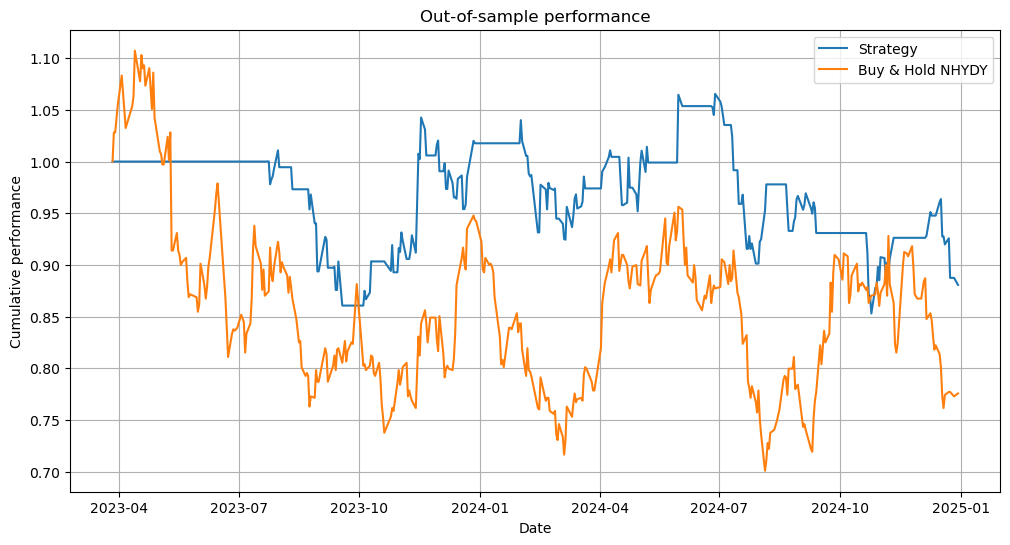

In [22]:
bt_test["strategy_equity"] = (1 + bt_test["strategy_ret"].fillna(0)).cumprod()
test_df["bh_equity"] = (1 + bh_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(bt_test["Date"], bt_test["strategy_equity"], label="Strategy")
plt.plot(test_df["Date"], test_df["bh_equity"], label=f"Buy & Hold {best_equity}")
plt.title("Out-of-sample performance")
plt.xlabel("Date")
plt.ylabel("Cumulative performance")
plt.legend()
plt.grid(True)
plt.show()

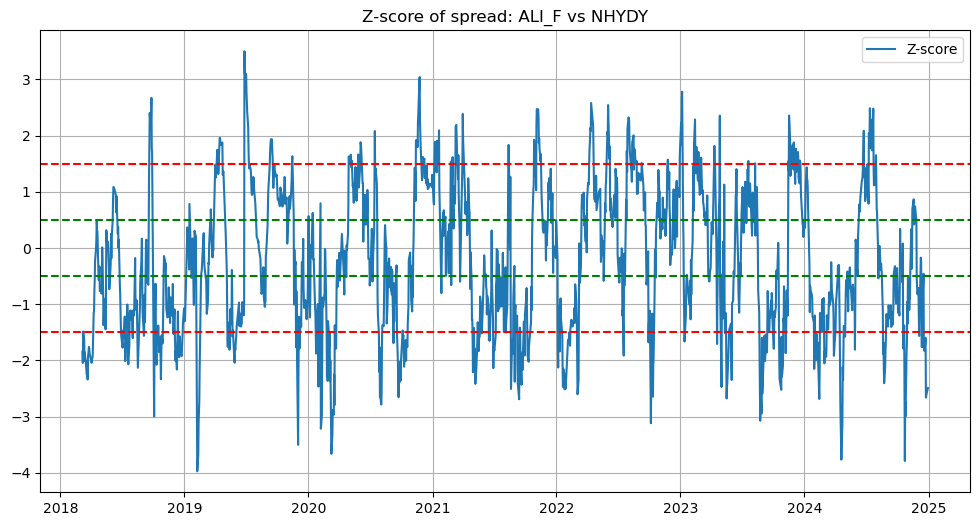

In [23]:
pair_df["zscore"] = compute_zscore(pair_df["spread"], best_lookback)

plt.figure(figsize=(12,6))
plt.plot(pair_df["Date"], pair_df["zscore"], label="Z-score")
plt.axhline(1.5, linestyle="--", color="red")
plt.axhline(-1.5, linestyle="--", color="red")
plt.axhline(0.5, linestyle="--", color="green")
plt.axhline(-0.5, linestyle="--", color="green")
plt.title(f"Z-score of spread: {anchor} vs {best_equity}")
plt.legend()
plt.grid(True)
plt.show()